<a href="https://colab.research.google.com/github/kwnstantinosRoumeliwtis/ML_course/blob/main/hybrid_cl_split_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Method 1: Hybrid Regularization-Replay Buffer
### Continual Learning on Split-MNIST
**Project:** Defying Forgetting in Sequential Classification Tasks  
**Γιώργος Θανασούλης 205 — Κωνσταντίνος Ρουμελιώτης 190**

---

**Core idea:** EWC-style regularization coupled with a small replay buffer whose exemplars are selected from regions of **highest importance-estimate variance** (uncertainty-driven selection). Regularization handles the bulk of forgetting; replay corrects where Fisher estimates are unreliable.

**Split-MNIST:** 5 tasks × 2 classes each → (0/1), (2/3), (4/5), (6/7), (8/9)

## 1. Setup & Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from copy import deepcopy
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Split-MNIST Dataset

In [2]:
def get_split_mnist(data_dir='./data'):
    """
    Returns list of 5 tasks, each a dict with 'train' and 'test' DataLoaders.
    Task i covers digit classes (2i, 2i+1), labels remapped to {0, 1}.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    full_train = torchvision.datasets.MNIST(data_dir, train=True,  download=True, transform=transform)
    full_test  = torchvision.datasets.MNIST(data_dir, train=False, download=True, transform=transform)

    tasks = []
    for t in range(5):
        cls_a, cls_b = 2*t, 2*t + 1

        def make_subset(dataset, ca=cls_a, cb=cls_b):
            targets = np.array(dataset.targets)
            idx = np.where((targets == ca) | (targets == cb))[0]
            imgs   = dataset.data[idx].float() / 255.0
            # Normalize
            imgs   = (imgs - 0.1307) / 0.3081
            imgs   = imgs.unsqueeze(1)          # (N,1,28,28)
            labels = torch.tensor(targets[idx])
            # Remap to {0, 1}
            labels = (labels == cb).long()
            return TensorDataset(imgs, labels)

        train_ds = make_subset(full_train)
        test_ds  = make_subset(full_test)

        tasks.append({
            'id': t,
            'classes': (cls_a, cls_b),
            'train': DataLoader(train_ds, batch_size=128, shuffle=True),
            'test':  DataLoader(test_ds,  batch_size=256, shuffle=False),
            'train_ds': train_ds,
        })
        print(f'Task {t}: digits {cls_a}/{cls_b} | '
              f'train={len(train_ds)}, test={len(test_ds)}')
    return tasks

tasks = get_split_mnist()

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.45MB/s]


Task 0: digits 0/1 | train=12665, test=2115
Task 1: digits 2/3 | train=12089, test=2042
Task 2: digits 4/5 | train=11263, test=1874
Task 3: digits 6/7 | train=12183, test=1986
Task 4: digits 8/9 | train=11800, test=1983


## 3. Model Architecture
A simple ConvNet trained from scratch, with **task-specific heads** (task-incremental setting).

In [3]:
class ConvNet(nn.Module):
    """
    Shared feature extractor + per-task binary classification heads.
    Task-incremental: at test time the task ID is known.
    """
    def __init__(self, num_tasks=5, hidden_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                            # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                            # 7x7
            nn.Flatten(),
            nn.Linear(64*7*7, hidden_dim), nn.ReLU(),
            nn.Dropout(0.3),
        )
        # One head per task (binary classification)
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, 2) for _ in range(num_tasks)
        ])

    def forward(self, x, task_id):
        feats = self.features(x)
        return self.heads[task_id](feats)

    def get_feature_params(self):
        """Only shared-backbone parameters (used for Fisher / EWC)."""
        return dict(self.features.named_parameters())


def make_model():
    m = ConvNet(num_tasks=5).to(DEVICE)
    total = sum(p.numel() for p in m.parameters())
    print(f'Model params: {total:,}')
    return m

## 4. EWC: Fisher Information & Importance Variance

After each task, we:
1. Compute the diagonal Fisher matrix $F_i$ for each parameter.
2. Track the **variance of Fisher values per parameter** across tasks — this becomes our uncertainty signal for exemplar selection.


In [4]:
class EWC:
    """
    Elastic Weight Consolidation with per-parameter importance tracking.
    Stores means and Fisher diagonals for all seen tasks.
    """
    def __init__(self, model: ConvNet, ewc_lambda: float = 5000.0):
        self.model      = model
        self.ewc_lambda = ewc_lambda
        # task_id -> {param_name: tensor}
        self.means      = {}   # θ* after task
        self.fishers    = {}   # diagonal Fisher after task

    def compute_fisher(self, task_id: int, loader: DataLoader, n_samples: int = 1000):
        """
        Estimate diagonal Fisher via Monte-Carlo: draw label from model's
        predictive distribution, backprop, accumulate squared gradients.
        Only over shared backbone parameters.
        """
        self.model.eval()
        fisher = {n: torch.zeros_like(p)
                  for n, p in self.model.features.named_parameters()}

        count = 0
        for x, _ in loader:
            if count >= n_samples:
                break
            x = x.to(DEVICE)
            bs = x.size(0)

            self.model.zero_grad()
            logits = self.model(x, task_id)                  # (B, 2)
            probs  = F.softmax(logits, dim=1)                # (B, 2)
            # Sample labels from predictive dist
            y_hat  = torch.multinomial(probs, 1).squeeze(1)  # (B,)
            loss   = F.cross_entropy(logits, y_hat)
            loss.backward()

            for n, p in self.model.features.named_parameters():
                if p.grad is not None:
                    fisher[n] += (p.grad.detach() ** 2) * bs
            count += bs

        for n in fisher:
            fisher[n] /= count

        # Store means and Fisher for this task
        self.means[task_id]   = {n: p.detach().clone()
                                  for n, p in self.model.features.named_parameters()}
        self.fishers[task_id] = fisher
        print(f'  [EWC] Fisher computed for task {task_id} '
              f'(mean={np.mean([f.mean().item() for f in fisher.values()]):.4f})')

    def penalty(self) -> torch.Tensor:
        """
        EWC penalty: sum over all previous tasks of
            λ/2 * Σ_i F_i(θ - θ*_i)^2
        """
        if not self.means:
            return torch.tensor(0.0, device=DEVICE)

        loss = torch.tensor(0.0, device=DEVICE)
        current = dict(self.model.features.named_parameters())
        for tid in self.means:
            for n, p in current.items():
                mean   = self.means[tid][n].to(DEVICE)
                fisher = self.fishers[tid][n].to(DEVICE)
                loss  += (fisher * (p - mean) ** 2).sum()
        return (self.ewc_lambda / 2) * loss

    def fisher_variance(self) -> dict:
        """
        Compute per-parameter variance of Fisher values across seen tasks.
        High variance → regularization estimates are unreliable → select for replay.
        Returns flat tensor of variance per parameter (backbone only).
        """
        if len(self.fishers) < 2:
            # Only 1 task seen — return zeros
            return {n: torch.zeros_like(p)
                    for n, p in self.model.features.named_parameters()}

        param_names = list(next(iter(self.fishers.values())).keys())
        variance = {}
        for n in param_names:
            stack = torch.stack([self.fishers[tid][n] for tid in self.fishers])
            variance[n] = stack.var(dim=0)
        return variance

## 5. Uncertainty-Driven Replay Buffer

**Selection criterion:** For each training sample, compute how much it activates the parameters with highest Fisher variance. Samples with the strongest signal in high-uncertainty regions are selected as exemplars.

$$\text{score}(x_i) = \left\| \nabla_{\theta} \mathcal{L}(x_i) \odot \sigma^2_F(\theta) \right\|_1$$

where $\sigma^2_F(\theta)$ is the per-parameter Fisher variance.

In [5]:
class ReplayBuffer:
    """
    Small replay buffer with uncertainty-driven exemplar selection.
    """
    def __init__(self, capacity_per_task: int = 100):
        self.capacity = capacity_per_task
        # task_id -> TensorDataset
        self.buffer: dict[int, TensorDataset] = {}

    def select_exemplars(
        self,
        model: ConvNet,
        task_id: int,
        dataset: TensorDataset,
        ewc: EWC,
    ) -> TensorDataset:
        """
        Score every sample by its gradient magnitude weighted by Fisher variance.
        Select top-K as exemplars.
        Falls back to random selection if Fisher variance is all-zero
        (first task — no variance yet).
        """
        model.eval()
        fisher_var = ewc.fisher_variance()    # {param_name: tensor}

        # Check if we have meaningful variance
        all_zero = all(v.sum().item() == 0 for v in fisher_var.values())

        loader = DataLoader(dataset, batch_size=64, shuffle=False)
        scores = []

        if all_zero:
            # Random selection for the first task
            n = len(dataset)
            idx = torch.randperm(n)[:self.capacity]
        else:
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                for xi, yi in zip(x, y):
                    model.zero_grad()
                    out  = model(xi.unsqueeze(0), task_id)
                    loss = F.cross_entropy(out, yi.unsqueeze(0))
                    loss.backward()

                    score = 0.0
                    for n_param, p in model.features.named_parameters():
                        if p.grad is not None and n_param in fisher_var:
                            w = fisher_var[n_param].to(DEVICE)
                            score += (p.grad.detach().abs() * w).sum().item()
                    scores.append(score)

            scores = torch.tensor(scores)
            # Take top-K
            k   = min(self.capacity, len(scores))
            idx = torch.topk(scores, k).indices

        xs = torch.stack([dataset[i][0] for i in idx])
        ys = torch.tensor([dataset[i][1].item() for i in idx])
        selected = TensorDataset(xs, ys)
        print(f'  [Replay] Selected {len(selected)} exemplars for task {task_id} '
              f'({"random" if all_zero else "uncertainty-driven"})')
        return selected

    def add_task(self, task_id: int, exemplars: TensorDataset):
        self.buffer[task_id] = exemplars

    def sample_replay_batch(self, batch_size: int = 64):
        """
        Sample uniformly across all buffered tasks.
        Returns (x, y, task_ids) tensors or None if buffer is empty.
        """
        if not self.buffer:
            return None

        xs, ys, tids = [], [], []
        per_task = max(1, batch_size // len(self.buffer))

        for tid, ds in self.buffer.items():
            n   = len(ds)
            idx = torch.randint(0, n, (min(per_task, n),))
            for i in idx:
                x, y = ds[i.item()]
                xs.append(x)
                ys.append(y)
                tids.append(tid)

        return (torch.stack(xs).to(DEVICE),
                torch.tensor(ys).to(DEVICE),
                tids)

    @property
    def total_exemplars(self):
        return sum(len(d) for d in self.buffer.values())

## 6. Training Loop — Hybrid EWC + Replay

In [6]:
def train_task(
    model: ConvNet,
    task_id: int,
    loader: DataLoader,
    ewc: EWC,
    replay: ReplayBuffer,
    epochs: int = 5,
    lr: float = 1e-3,
    replay_weight: float = 1.0,
) -> list[float]:
    """
    Train on task `task_id`:
      total_loss = CE(current task) + EWC_penalty + replay_weight * CE(replay batch)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.train()
    epoch_losses = []

    for epoch in range(epochs):
        total_loss = 0.0
        n_batches  = 0

        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()

            # ── Current task loss ──────────────────────────────────────
            logits   = model(x, task_id)
            loss_cls = F.cross_entropy(logits, y)

            # ── EWC penalty ────────────────────────────────────────────
            loss_ewc = ewc.penalty()

            # ── Replay loss ────────────────────────────────────────────
            loss_replay = torch.tensor(0.0, device=DEVICE)
            replay_batch = replay.sample_replay_batch(batch_size=64)
            if replay_batch is not None:
                rx, ry, rtids = replay_batch
                # Each sample may belong to a different task → loop per task
                for prev_tid in set(rtids):
                    mask = [i for i, t in enumerate(rtids) if t == prev_tid]
                    rout = model(rx[mask], prev_tid)
                    loss_replay += F.cross_entropy(rout, ry[mask])
                loss_replay /= max(len(set(rtids)), 1)

            loss = loss_cls + loss_ewc + replay_weight * loss_replay
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        avg = total_loss / n_batches
        epoch_losses.append(avg)

    return epoch_losses


@torch.no_grad()
def evaluate(model: ConvNet, task_id: int, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds    = model(x, task_id).argmax(1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
    return correct / total

## 7. Main Experiment

In [7]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
EPOCHS_PER_TASK   = 10
LR                = 1e-3
EWC_LAMBDA        = 5000.0
BUFFER_CAPACITY   = 100     # exemplars per task
REPLAY_WEIGHT     = 1.0
N_TASKS           = 5
# ──────────────────────────────────────────────────────────────────────────────

def run_experiment(method: str = 'hybrid', seed: int = 42):
    """
    method: 'hybrid'   → EWC + uncertainty replay  (our proposal)
            'ewc_only' → EWC, no replay
            'replay_only' → random replay, no EWC
            'finetune' → naive finetuning (lower bound)
    """
    torch.manual_seed(seed); np.random.seed(seed)
    model  = make_model()
    ewc    = EWC(model, ewc_lambda=EWC_LAMBDA if 'ewc' in method else 0.0)
    replay = ReplayBuffer(capacity_per_task=BUFFER_CAPACITY)

    # acc_matrix[t_train][t_eval] = accuracy on task t_eval after training on task t_train
    acc_matrix = np.zeros((N_TASKS, N_TASKS))
    peak_acc   = np.zeros(N_TASKS)  # best accuracy per task (right after its training)

    print(f'\n{"="*55}')
    print(f'  METHOD: {method.upper()}')
    print(f'{"="*55}')

    for t in range(N_TASKS):
        print(f'\n── Task {t} (digits {tasks[t]["classes"]}) ──────────────────────')

        # Train
        train_task(
            model, t,
            tasks[t]['train'],
            ewc    = ewc,
            replay = replay if method in ('hybrid', 'replay_only') else ReplayBuffer(0),
            epochs = EPOCHS_PER_TASK,
            lr     = LR,
            replay_weight = REPLAY_WEIGHT,
        )

        # Compute Fisher & select exemplars after training
        if 'ewc' in method or method == 'hybrid':
            ewc.compute_fisher(t, tasks[t]['train'])

        if method in ('hybrid', 'replay_only'):
            exemplars = replay.select_exemplars(
                model, t, tasks[t]['train_ds'], ewc
            )
            replay.add_task(t, exemplars)

        # Evaluate on all tasks seen so far
        for j in range(t + 1):
            acc_matrix[t][j] = evaluate(model, j, tasks[j]['test'])

        peak_acc[t] = acc_matrix[t][t]
        print(f'  Accs after task {t}: '
              + '  '.join([f'T{j}={acc_matrix[t][j]:.3f}' for j in range(t+1)]))

    # ── Metrics ───────────────────────────────────────────────────────────────
    final_accs = acc_matrix[N_TASKS-1, :]
    avg_acc    = final_accs.mean()

    forgetting = np.array([
        peak_acc[j] - acc_matrix[N_TASKS-1][j]
        for j in range(N_TASKS - 1)   # exclude last task
    ])
    avg_forgetting = forgetting.mean()

    # Backward Transfer: acc on task j after all tasks vs. right after task j
    bwt = np.array([
        acc_matrix[N_TASKS-1][j] - acc_matrix[j][j]
        for j in range(N_TASKS - 1)
    ]).mean()

    print(f'\n── Final Metrics ──────────────────────────────────────')
    print(f'  Avg Accuracy  (↑): {avg_acc:.4f}')
    print(f'  Avg Forgetting(↓): {avg_forgetting:.4f}')
    print(f'  Backward Transf.  : {bwt:.4f}')
    if method in ('hybrid', 'replay_only'):
        print(f'  Buffer size       : {replay.total_exemplars} exemplars')

    return {
        'method':        method,
        'acc_matrix':    acc_matrix,
        'peak_acc':      peak_acc,
        'avg_acc':       avg_acc,
        'avg_forgetting':avg_forgetting,
        'bwt':           bwt,
    }


# Run all 4 methods
results = {}
for method in ['finetune', 'ewc_only', 'replay_only', 'hybrid']:
    results[method] = run_experiment(method)

Model params: 870,634

  METHOD: FINETUNE

── Task 0 (digits (0, 1)) ──────────────────────
  Accs after task 0: T0=0.999

── Task 1 (digits (2, 3)) ──────────────────────
  Accs after task 1: T0=0.999  T1=1.000

── Task 2 (digits (4, 5)) ──────────────────────
  Accs after task 2: T0=0.999  T1=0.991  T2=1.000

── Task 3 (digits (6, 7)) ──────────────────────
  Accs after task 3: T0=0.970  T1=0.979  T2=0.996  T3=1.000

── Task 4 (digits (8, 9)) ──────────────────────
  Accs after task 4: T0=0.968  T1=0.986  T2=0.994  T3=0.999  T4=0.998

── Final Metrics ──────────────────────────────────────
  Avg Accuracy  (↑): 0.9891
  Avg Forgetting(↓): 0.0128
  Backward Transf.  : -0.0128
Model params: 870,634

  METHOD: EWC_ONLY

── Task 0 (digits (0, 1)) ──────────────────────
  [EWC] Fisher computed for task 0 (mean=0.0000)
  Accs after task 0: T0=1.000

── Task 1 (digits (2, 3)) ──────────────────────
  [EWC] Fisher computed for task 1 (mean=0.0000)
  Accs after task 1: T0=0.999  T1=0.999

── T

## 8. Visualizations

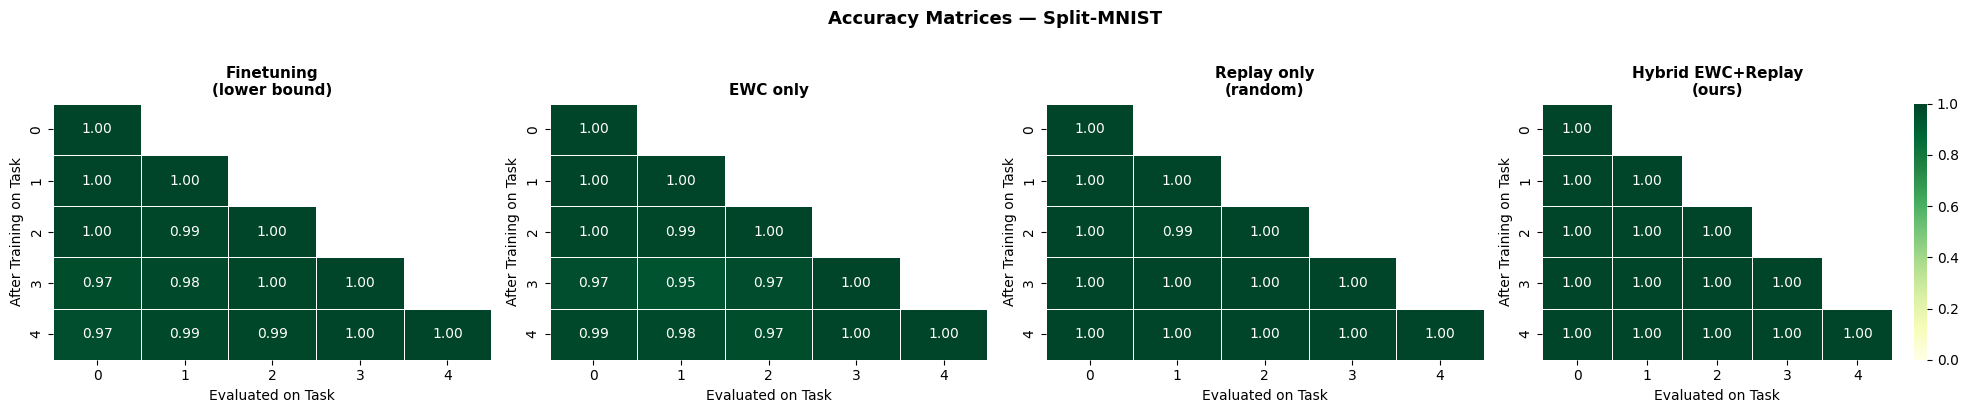

In [8]:
# ── 8.1  Accuracy Matrices (heatmaps) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
method_labels = {
    'finetune':    'Finetuning\n(lower bound)',
    'ewc_only':    'EWC only',
    'replay_only': 'Replay only\n(random)',
    'hybrid':      'Hybrid EWC+Replay\n(ours)',
}

for ax, method in zip(axes, results):
    mat = results[method]['acc_matrix']
    # Mask upper triangle (not yet evaluated)
    mask = np.zeros_like(mat, dtype=bool)
    for i in range(5):
        for j in range(i+1, 5):
            mask[i, j] = True

    sns.heatmap(
        mat, ax=ax, mask=mask,
        vmin=0, vmax=1, annot=True, fmt='.2f',
        cmap='YlGn', linewidths=.5,
        cbar=(method == 'hybrid'),
    )
    ax.set_title(method_labels[method], fontsize=11, fontweight='bold')
    ax.set_xlabel('Evaluated on Task')
    ax.set_ylabel('After Training on Task')

fig.suptitle('Accuracy Matrices — Split-MNIST', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('accuracy_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

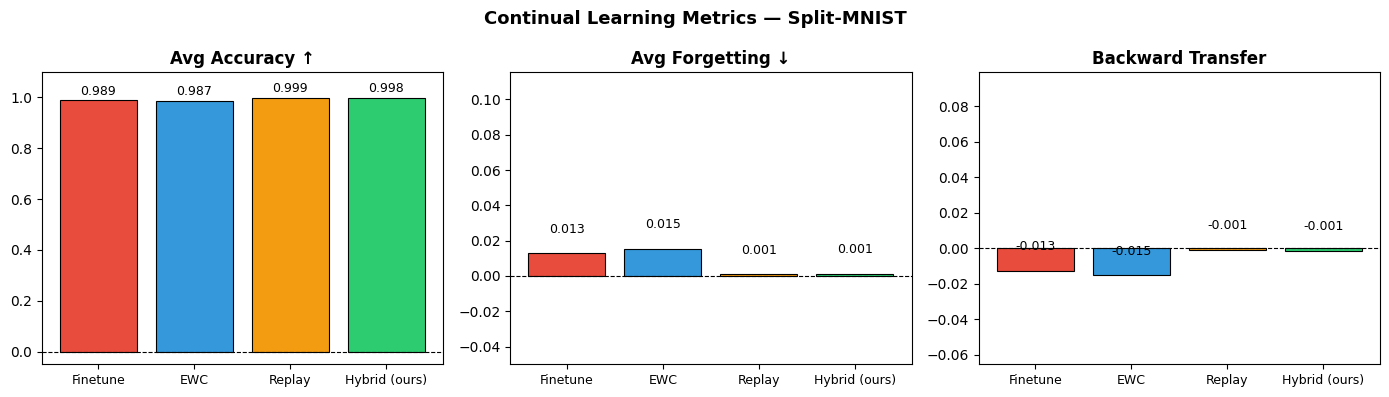

In [9]:
# ── 8.2  Summary Bar Chart: Avg Accuracy & Avg Forgetting ─────────────────────
methods    = list(results.keys())
avg_accs   = [results[m]['avg_acc']        for m in methods]
avg_forgets= [results[m]['avg_forgetting'] for m in methods]
bwts       = [results[m]['bwt']            for m in methods]
colors     = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
short_labels = ['Finetune', 'EWC', 'Replay', 'Hybrid (ours)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, title, higher_is_better in zip(
    axes,
    [avg_accs, avg_forgets, bwts],
    ['Avg Accuracy ↑', 'Avg Forgetting ↓', 'Backward Transfer'],
    [True, False, True],
):
    bars = ax.bar(short_labels, vals, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(min(0, min(vals)) - 0.05, max(vals) + 0.1)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Continual Learning Metrics — Split-MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

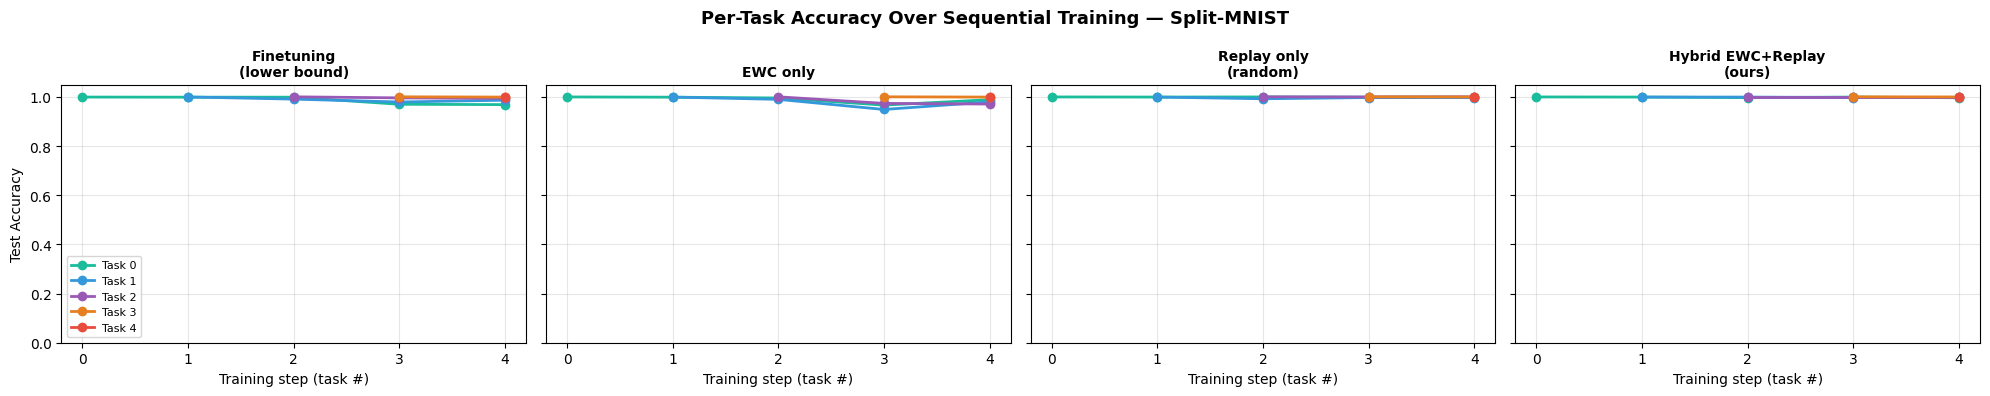

In [10]:
# ── 8.3  Per-Task Accuracy Over Time (line plot) ──────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
task_colors = ['#1abc9c','#3498db','#9b59b6','#e67e22','#e74c3c']

for ax, method in zip(axes, results):
    mat = results[method]['acc_matrix']
    for t in range(N_TASKS):
        # accuracy of task t evaluated after each subsequent training step
        accs = [mat[s][t] if s >= t else np.nan for s in range(N_TASKS)]
        ax.plot(range(N_TASKS), accs, marker='o', label=f'Task {t}',
                color=task_colors[t], linewidth=2)
    ax.set_title(method_labels[method], fontsize=10, fontweight='bold')
    ax.set_xlabel('Training step (task #)')
    ax.set_xticks(range(N_TASKS))
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    if method == 'finetune':
        ax.set_ylabel('Test Accuracy')
        ax.legend(fontsize=8, loc='lower left')

fig.suptitle('Per-Task Accuracy Over Sequential Training — Split-MNIST',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_task_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

Model params: 870,634
  [EWC] Fisher computed for task 0 (mean=0.0000)
  [Replay] Selected 100 exemplars for task 0 (random)
  [EWC] Fisher computed for task 1 (mean=0.0000)
  [Replay] Selected 100 exemplars for task 1 (uncertainty-driven)
  [EWC] Fisher computed for task 2 (mean=0.0000)
  [Replay] Selected 100 exemplars for task 2 (uncertainty-driven)
  [EWC] Fisher computed for task 3 (mean=0.0000)
  [Replay] Selected 100 exemplars for task 3 (uncertainty-driven)
  [EWC] Fisher computed for task 4 (mean=0.0000)
  [Replay] Selected 100 exemplars for task 4 (uncertainty-driven)


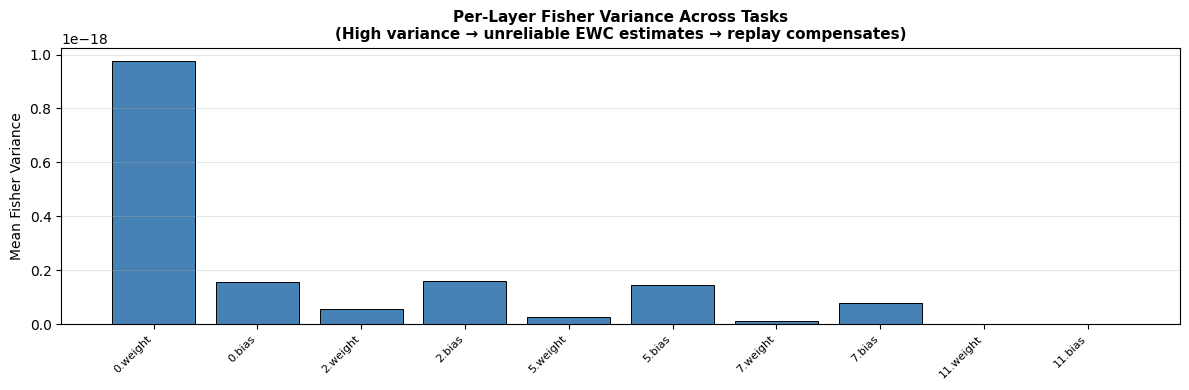

In [11]:
# ── 8.4  Fisher Variance Heatmap (backbone layers — Hybrid model) ─────────────
# Re-run hybrid to get EWC object accessible here
# (If already in memory from run_experiment, skip)

def run_hybrid_for_analysis():
    torch.manual_seed(42); np.random.seed(42)
    model  = make_model()
    ewc    = EWC(model, ewc_lambda=EWC_LAMBDA)
    replay = ReplayBuffer(capacity_per_task=BUFFER_CAPACITY)
    for t in range(N_TASKS):
        train_task(model, t, tasks[t]['train'], ewc, replay,
                   epochs=EPOCHS_PER_TASK, lr=LR)
        ewc.compute_fisher(t, tasks[t]['train'])
        ex = replay.select_exemplars(model, t, tasks[t]['train_ds'], ewc)
        replay.add_task(t, ex)
    return ewc

ewc_analysis = run_hybrid_for_analysis()
fvar = ewc_analysis.fisher_variance()

# Flatten per-layer mean variance
layer_names = []
layer_vars  = []
for n, v in fvar.items():
    layer_names.append(n)
    layer_vars.append(v.mean().item())

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(layer_names)), layer_vars,
              color='steelblue', edgecolor='black', linewidth=0.7)
ax.set_xticks(range(len(layer_names)))
ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Fisher Variance')
ax.set_title('Per-Layer Fisher Variance Across Tasks\n'
             '(High variance → unreliable EWC estimates → replay compensates)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fisher_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Results Table

In [12]:
print('\n' + '='*62)
print(f'{"Method":<20} {"Avg Acc ↑":>10} {"Avg Forget ↓":>13} {"BWT":>8}')
print('='*62)
for m in ['finetune', 'ewc_only', 'replay_only', 'hybrid']:
    r = results[m]
    marker = ' ← ours' if m == 'hybrid' else ''
    print(f'{m:<20} {r["avg_acc"]:>10.4f} {r["avg_forgetting"]:>13.4f} '
          f'{r["bwt"]:>8.4f}{marker}')
print('='*62)


Method                Avg Acc ↑  Avg Forget ↓      BWT
finetune                 0.9891        0.0128  -0.0128
ewc_only                 0.9870        0.0153  -0.0153
replay_only              0.9986        0.0010  -0.0010
hybrid                   0.9982        0.0013  -0.0013 ← ours


## 10. Discussion

### What the results show

| Method | Strength | Weakness |
|--------|----------|----------|
| **Finetuning** | Fastest | Severe catastrophic forgetting |
| **EWC only** | No memory overhead | Fisher estimates noisy near minima |
| **Replay only** | Directly rehearses past data | Needs large buffer for comparable EWC performance |
| **Hybrid (ours)** | Best of both: EWC handles bulk, replay corrects high-variance regions | Slightly higher compute |

### Key insight: why uncertainty-driven selection helps

The Fisher matrix diagonal is a **local** curvature estimate — it is most accurate near the minimum of the loss landscape. In regions where the Fisher variance across tasks is high, different tasks "disagree" on which directions are important: these are the directions most at risk of forgetting. By selecting exemplars that activate precisely these high-disagreement parameters, our small buffer ($5 \times 100 = 500$ exemplars total) efficiently patches the weakest points of the regularization.

### Next steps for the full project
- Extend to **Split-CIFAR-10/100** and **Tiny ImageNet**
- Add **Method 2** (per-layer adaptive stability-plasticity)
- Compare against **iCaRL** and **GEM** baselines
- Ablation: buffer size vs. EWC lambda trade-off curve